In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp

# ==========================================
# 1. Physical Parameters
# ==========================================
L = 0.05
H = 0.01
U_inf = 1.0
T_inf = 300.0
T_wall = 350.0

nu = 1.5e-5
Pr = 0.6818
alpha = nu / Pr

nx = 1600
ny = 960
dx = L / nx
dy = H / ny

# Avoid x=0 exactly to prevent division by zero in similarity variable
x = np.linspace(dx, L, nx)
y = np.linspace(0, H, ny)
X, Y = np.meshgrid(x, y)

# ==========================================
# 2. Solve Coupled Blasius and Energy ODEs
# ==========================================
# y_bvp variables:
# f   = y_bvp[0]
# f'  = y_bvp[1]
# f'' = y_bvp[2]
# T*  = y_bvp[3] (Theta)
# T*' = y_bvp[4]
def boundary_layer_ode(eta, y_bvp):
    f, f_prime, f_double_prime, theta, theta_prime = y_bvp
    
    df_deta = f_prime
    df_prime_deta = f_double_prime
    df_double_prime_deta = -0.5 * f * f_double_prime
    
    dtheta_deta = theta_prime
    dtheta_prime_deta = -0.5 * Pr * f * theta_prime
    
    return np.vstack((df_deta, df_prime_deta, df_double_prime_deta, 
                      dtheta_deta, dtheta_prime_deta))

def boundary_conditions(ya, yb):
    # Wall conditions (eta = 0)
    f_0 = ya[0]
    f_prime_0 = ya[1]
    theta_0 = ya[3]
    
    # Freestream conditions (eta = infinity)
    f_prime_inf = yb[1] - 1.0
    theta_inf = yb[3] - 1.0
    
    return np.array([f_0, f_prime_0, theta_0, f_prime_inf, theta_inf])

eta_max_bvp = 10.0
eta_theory = np.linspace(0, eta_max_bvp, 500)

# Initial guess
y_guess = np.zeros((5, eta_theory.size))
y_guess[1, :] = 1.0  # f' guess
y_guess[3, :] = 1.0  # Theta guess

blasius_sol = solve_bvp(boundary_layer_ode, boundary_conditions, eta_theory, y_guess)

# ==========================================
# 3. Map 1D Solution to 2D Physical Domain
# ==========================================
Eta = Y * np.sqrt(U_inf / (nu * X))

# Flatten arrays for vectorized piecewise evaluation
eta_flat = Eta.flatten()
f_flat = np.zeros_like(eta_flat)
f_prime_flat = np.ones_like(eta_flat)
theta_flat = np.ones_like(eta_flat)

# Mask for nodes inside vs outside the solved boundary layer thickness
inside = eta_flat <= eta_max_bvp
outside = eta_flat > eta_max_bvp

# Evaluate exact BVP interpolant for nodes inside the boundary layer
res_inside = blasius_sol.sol(eta_flat[inside])
f_flat[inside] = res_inside[0]
f_prime_flat[inside] = res_inside[1]
theta_flat[inside] = res_inside[3]

# Apply freestream asymptotics for nodes outside the boundary layer
f_max = blasius_sol.sol(eta_max_bvp)[0]
f_flat[outside] = f_max + (eta_flat[outside] - eta_max_bvp) # f grows linearly as f' -> 1
f_prime_flat[outside] = 1.0
theta_flat[outside] = 1.0

# Reshape back to 2D physical grid
f_grid = f_flat.reshape(X.shape)
f_prime_grid = f_prime_flat.reshape(X.shape)
theta_grid = theta_flat.reshape(X.shape)

# Dimensionalize the mapped variables
u_exact = U_inf * f_prime_grid
v_exact = 0.5 * np.sqrt(nu * U_inf / X) * (Eta * f_prime_grid - f_grid)
T_exact = T_wall + theta_grid * (T_inf - T_wall)

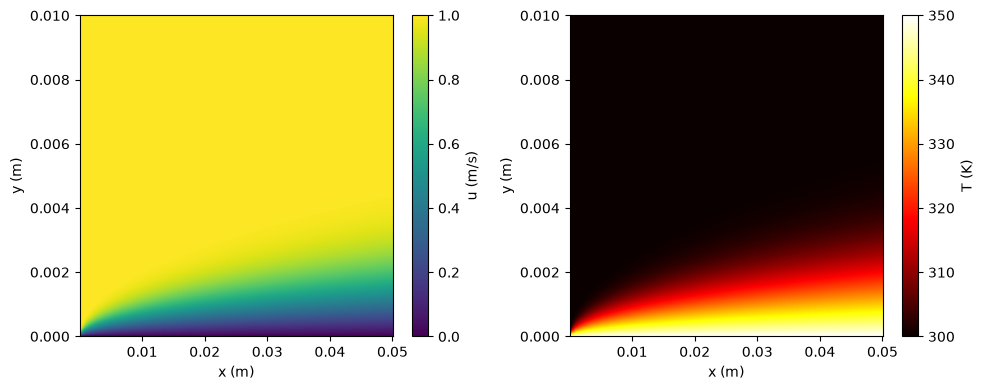

In [7]:
# ==========================================
# 4. Plotting and Saving
# ==========================================
delta_L = 5.0 * np.sqrt(nu * L / U_inf)
v_scale = U_inf * (delta_L / L)

#fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(10, 4))

# 1. Streamwise Velocity u (m/s)
c1 = ax1.pcolormesh(X, Y, u_exact, cmap='viridis', shading='auto')
cb1 = fig.colorbar(c1, ax=ax1)
cb1.set_label('u (m/s)') 
#ax1.set_title('Exact Velocity (u)')
ax1.set_xlabel('x (m)')
ax1.set_ylabel('y (m)')

# 2. Transverse Velocity v (m/s)
#c2 = ax2.pcolormesh(X, Y, v_exact, cmap='viridis', shading='auto', vmax=v_scale)
#cb2 = fig.colorbar(c2, ax=ax2)
#cb2.set_label('v (m/s)') 
#ax2.set_title('Exact Transverse Velocity (v)')
#ax2.set_xlabel('x (m)')
#ax2.set_ylabel('y (m)')

# 3. Temperature (K)
c3 = ax3.pcolormesh(X, Y, T_exact, cmap='hot', shading='auto')
cb3 = fig.colorbar(c3, ax=ax3)
cb3.set_label('T (K)')   
#ax3.set_title('Exact Temperature (T)')
ax3.set_xlabel('x (m)')
ax3.set_ylabel('y (m)')
plt.tight_layout()
# plt.savefig(file_path, format='pdf', bbox_inches='tight')
# plt.savefig('../lectures/figures/exact_similarity_solution.pdf',dpi=300)
plt.savefig('../lectures/figures/exact_similarity_solution.png')
plt.show()